# 🛒 BigMart Sales Prediction
## PI Consulting — Data Scientist Challenge

**Objetivo:** Construir un modelo de regresión para predecir `Item_Outlet_Sales`
e identificar los factores más influyentes en las ventas.

**Estructura del notebook:**
1. Carga y exploración de datos (EDA)
2. Limpieza y preprocesamiento
3. Feature Engineering (incluyendo interacciones y target encoding)
4. Modelado: Ridge · Random Forest · XGBoost · LightGBM · CatBoost · MLP · XGBoost+RandomSearch
5. Optuna tuning (búsqueda bayesiana de hiperparámetros)
6. Stacking ensemble con meta-learner
7. Comparación de modelos
8. Predicciones en test set

## 1. Imports y configuración

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# CatBoost
from catboost import CatBoostRegressor

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Paleta de colores
PALETTE = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#00BCD4"]
sns.set_theme(style="whitegrid", palette=PALETTE)

print("Librerías cargadas")
print(f"   scikit-learn: {__import__('sklearn').__version__}")
print(f"   XGBoost:      {xgb.__version__}")
print(f"   LightGBM:     {lgb.__version__}")
print(f"   CatBoost:     {__import__('catboost').__version__}")
print(f"   Optuna:       {optuna.__version__}")


✅ Librerías cargadas
   scikit-learn: 1.9.0
   XGBoost:      3.2.0
   LightGBM:     4.6.0
   CatBoost:     1.2.10
   Optuna:       4.9.0


## 2. Carga de datos

In [2]:
train = pd.read_csv("Train_BigMart.csv")
test  = pd.read_csv("Test_BigMart.csv")

print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
train.head()

Train: 8,523 filas x 12 columnas
Test:  5,681 filas x 11 columnas


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 3. Análisis Exploratorio (EDA)

### 3.1 Tipos de datos y valores nulos

In [3]:
info_df = pd.DataFrame({
    "Tipo": train.dtypes,
    "Nulos": train.isnull().sum(),
    "% Nulos": (train.isnull().mean() * 100).round(2),
    "Unicos": train.nunique(),
    "Ejemplo": train.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else None)
})
info_df

,Tipo,Nulos,% Nulos,Unicos,Ejemplo
Item_Identifier,object,0,0.00,1559,FDA15
Item_Weight,float64,1463,17.17,415,9.3
Item_Fat_Content,object,0,0.00,5,Low Fat
Item_Visibility,float64,0,0.00,7880,0.016047
Item_Type,object,0,0.00,16,Dairy
Item_MRP,float64,0,0.00,5938,249.8092
Outlet_Identifier,object,0,0.00,10,OUT049
Outlet_Establishment_Year,int64,0,0.00,9,1999
Outlet_Size,object,2410,28.28,3,Medium
Outlet_Location_Type,object,0,0.00,3,Tier 1


### 3.2 Distribución de la variable objetivo

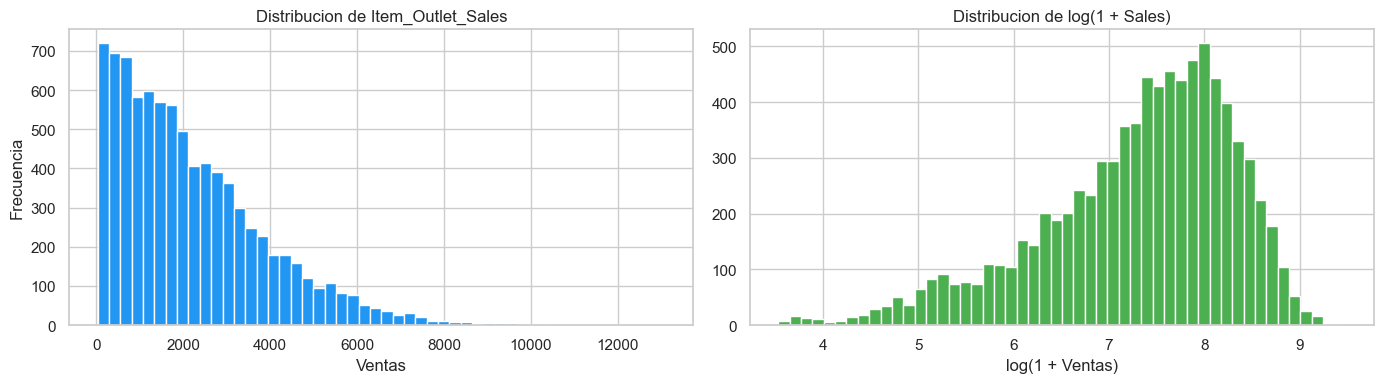

Asimetria (skewness): 1.178
La distribucion tiene cola derecha → log-transform mejora TODOS los modelos


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train["Item_Outlet_Sales"], bins=50, color=PALETTE[0], edgecolor="white")
axes[0].set_title("Distribucion de Item_Outlet_Sales")
axes[0].set_xlabel("Ventas")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(train["Item_Outlet_Sales"]), bins=50, color=PALETTE[1], edgecolor="white")
axes[1].set_title("Distribucion de log(1 + Sales)")
axes[1].set_xlabel("log(1 + Ventas)")

plt.tight_layout()
plt.show()

print("Asimetria (skewness):", round(train["Item_Outlet_Sales"].skew(), 3))
print("La distribucion tiene cola derecha → log-transform mejora TODOS los modelos")

### 3.3 Variables numéricas: correlación

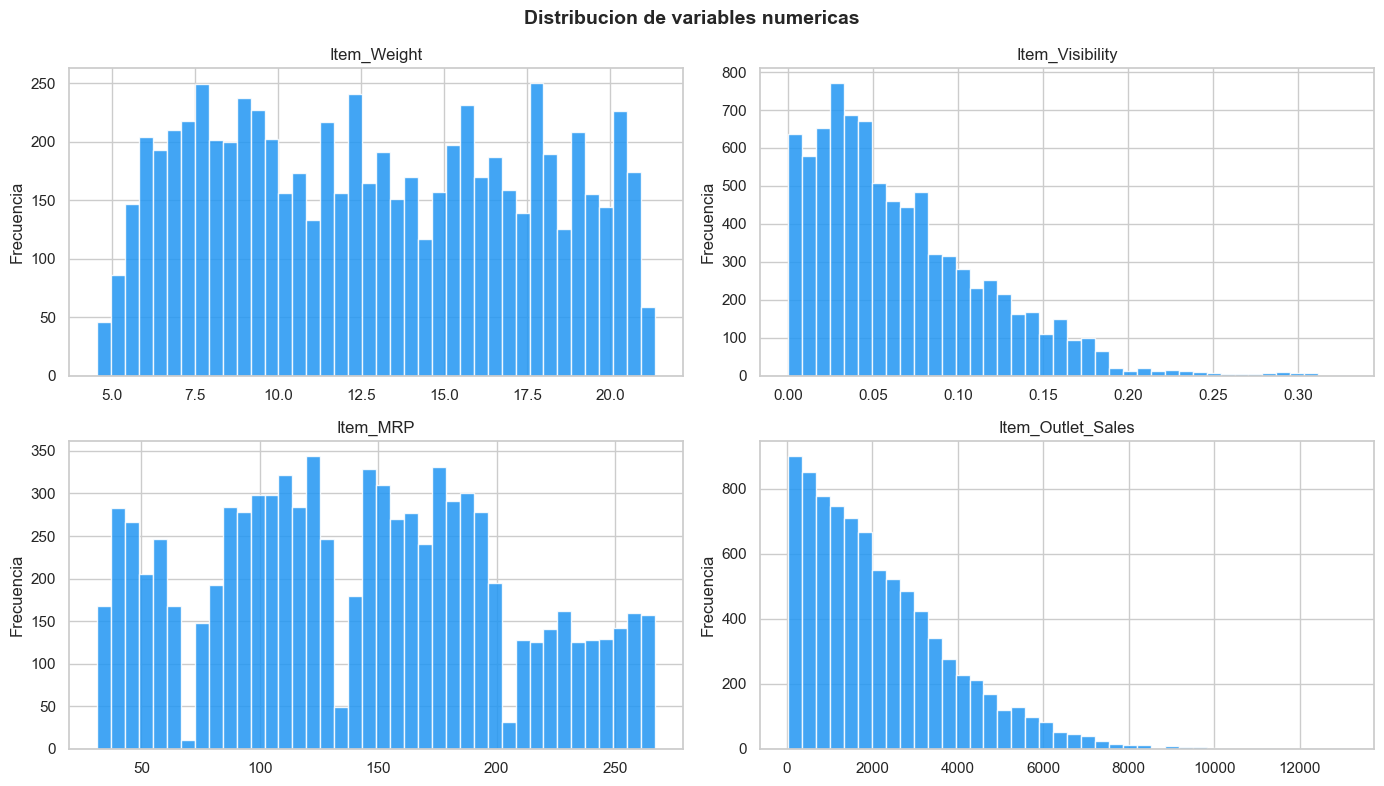

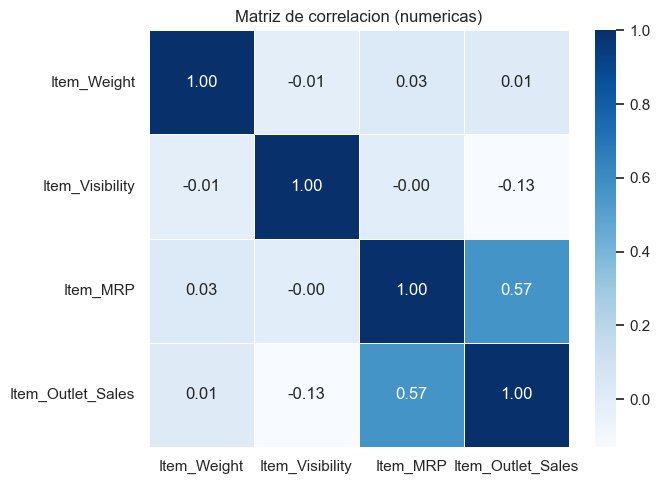

 Item_MRP es la variable numerica con mayor correlacion con las ventas.


In [5]:
num_cols = ["Item_Weight", "Item_Visibility", "Item_MRP", "Item_Outlet_Sales"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(train[col].dropna(), bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Frecuencia")
plt.suptitle("Distribucion de variables numericas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr = train[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax, linewidths=0.5)
ax.set_title("Matriz de correlacion (numericas)")
plt.tight_layout()
plt.show()

print(" Item_MRP es la variable numerica con mayor correlacion con las ventas.")

### 3.4 Ventas por tipo de tienda

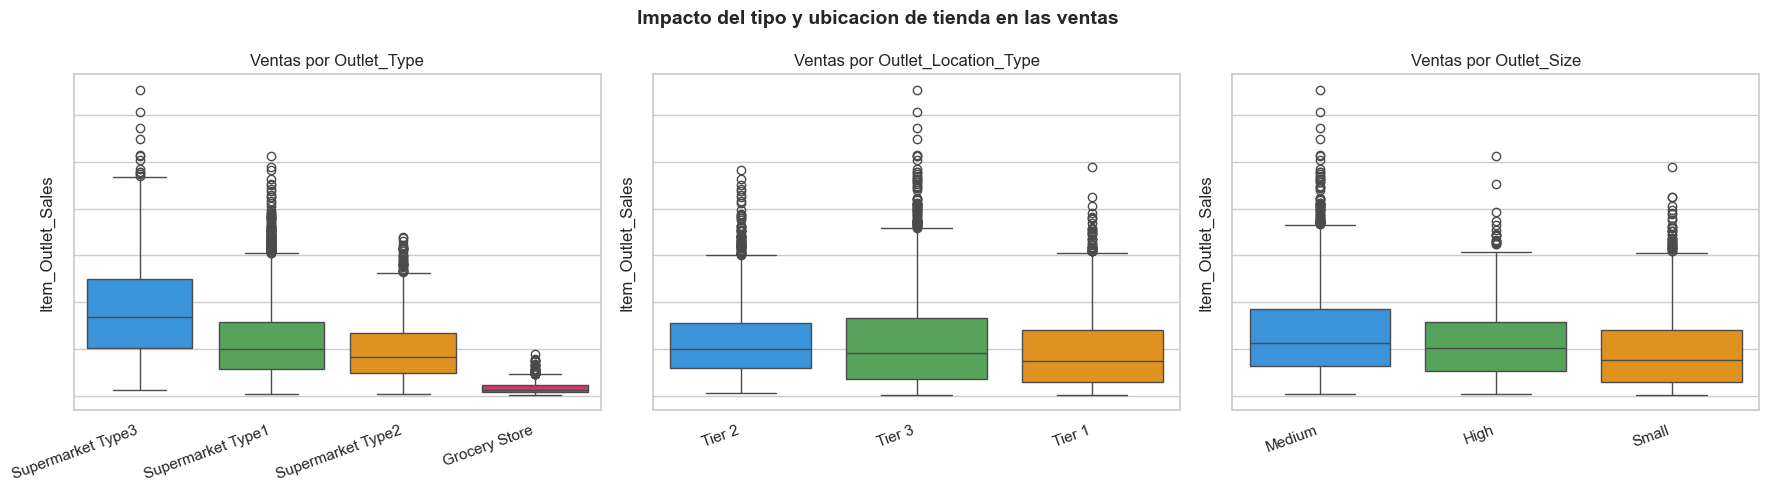

💡 Supermarket Type3 vende significativamente mas que el resto.
💡 Grocery Stores tienen ventas muy bajas (menos surtido).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["Outlet_Type", "Outlet_Location_Type", "Outlet_Size"]):
    order = train.groupby(col)["Item_Outlet_Sales"].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y="Item_Outlet_Sales", order=order, ax=ax, palette=PALETTE)
    ax.set_title(f"Ventas por {col}", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f""))

plt.suptitle("Impacto del tipo y ubicacion de tienda en las ventas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(" Supermarket Type3 vende significativamente mas que el resto.")
print(" Grocery Stores tienen ventas muy bajas (menos surtido).")

### 3.5 Ventas por tipo de producto

In [7]:
item_sales = (train.groupby("Item_Type")["Item_Outlet_Sales"]
              .median().sort_values(ascending=False).reset_index())

fig = px.bar(item_sales, x="Item_Outlet_Sales", y="Item_Type", orientation="h",
             color="Item_Outlet_Sales", color_continuous_scale="Blues",
             title="Ventas medianas por tipo de producto",
             labels={"Item_Outlet_Sales": "Mediana de Ventas", "Item_Type": "Tipo de Producto"})
fig.update_layout(height=500, showlegend=False)
fig.show()

### 3.6 Visibilidad vs Ventas

Items con visibilidad = 0: 526


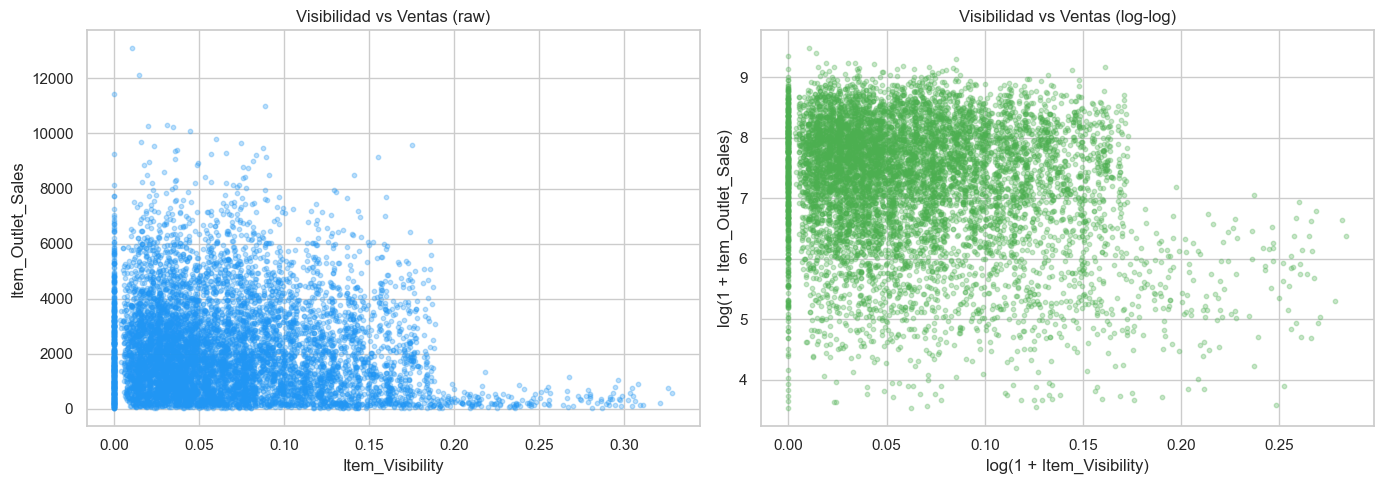

526 items con visibilidad 0 → imputacion con media por item.


In [8]:
print("Items con visibilidad = 0:", (train["Item_Visibility"] == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(train["Item_Visibility"], train["Item_Outlet_Sales"],
                alpha=0.3, color=PALETTE[0], s=10)
axes[0].set_xlabel("Item_Visibility")
axes[0].set_ylabel("Item_Outlet_Sales")
axes[0].set_title("Visibilidad vs Ventas (raw)")

axes[1].scatter(np.log1p(train["Item_Visibility"]), np.log1p(train["Item_Outlet_Sales"]),
                alpha=0.3, color=PALETTE[1], s=10)
axes[1].set_xlabel("log(1 + Item_Visibility)")
axes[1].set_ylabel("log(1 + Item_Outlet_Sales)")
axes[1].set_title("Visibilidad vs Ventas (log-log)")
plt.tight_layout()
plt.show()

print("526 items con visibilidad 0 → imputacion con media por item.")

## 4. Limpieza de datos

In [9]:
# Combinar train+test para procesar juntos
train["split"] = "train"
test["split"]  = "test"
test["Item_Outlet_Sales"] = np.nan
df = pd.concat([train, test], ignore_index=True)
print(f"Dataset combinado: {df.shape}")

Dataset combinado: (14204, 13)


In [10]:
# 4.1 Normalizar Item_Fat_Content
fat_map = {"LF": "Low Fat", "low fat": "Low Fat", "reg": "Regular"}
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace(fat_map)
non_food = ["Health and Hygiene", "Household", "Others"]
df.loc[df["Item_Type"].isin(non_food), "Item_Fat_Content"] = "Non-Edible"
print("Item_Fat_Content unicos:", df["Item_Fat_Content"].unique())

# 4.2 Imputar Item_Weight
item_weight_mean = df.groupby("Item_Identifier")["Item_Weight"].transform("mean")
df["Item_Weight"] = df["Item_Weight"].fillna(item_weight_mean).fillna(df["Item_Weight"].mean())
print(f"Nulos en Item_Weight: {df['Item_Weight'].isnull().sum()}")

# 4.3 Imputar Outlet_Size
outlet_size_mode = df.groupby("Outlet_Type")["Outlet_Size"].agg(
    lambda x: x.mode()[0] if not x.mode().empty else "Small"
)
df["Outlet_Size"] = df.apply(
    lambda row: outlet_size_mode[row["Outlet_Type"]] if pd.isna(row["Outlet_Size"]) else row["Outlet_Size"],
    axis=1
)
print(f"Nulos en Outlet_Size: {df['Outlet_Size'].isnull().sum()}")

# 4.4 Corregir Item_Visibility = 0
item_vis_mean = df.groupby("Item_Identifier")["Item_Visibility"].transform(
    lambda x: x[x > 0].mean() if (x > 0).any() else x.mean()
)
df.loc[df["Item_Visibility"] == 0, "Item_Visibility"] = item_vis_mean[df["Item_Visibility"] == 0]
print(f"Items con visibilidad 0 despues: {(df['Item_Visibility'] == 0).sum()}")

Item_Fat_Content unicos: ['Low Fat' 'Regular' 'Non-Edible']
Nulos en Item_Weight: 0
Nulos en Outlet_Size: 0
Items con visibilidad 0 despues: 0


## 5. Feature Engineering

###  Mejoras 1 y 2: Features de interacción + target encoding

In [11]:
# 5.1 Outlet_Age
df["Outlet_Age"] = 2013 - df["Outlet_Establishment_Year"]

# 5.2 Item_Visibility_MeanRatio
item_mean_vis = df.groupby("Item_Identifier")["Item_Visibility"].transform("mean")
df["Item_Visibility_MeanRatio"] = df["Item_Visibility"] / item_mean_vis

# 5.3 Item_Category amplia
food_map = {
    "Dairy": "Food", "Soft Drinks": "Drinks", "Meat": "Food",
    "Fruits and Vegetables": "Food", "Household": "Non-Consumable",
    "Baking Goods": "Food", "Snack Foods": "Food", "Frozen Foods": "Food",
    "Breakfast": "Food", "Health and Hygiene": "Non-Consumable",
    "Hard Drinks": "Drinks", "Canned": "Food", "Breads": "Food",
    "Starchy Foods": "Food", "Others": "Non-Consumable", "Seafood": "Food"
}
df["Item_Category"] = df["Item_Type"].map(food_map)

# 5.4 MRP bins
df["MRP_Tier"] = pd.qcut(df["Item_MRP"], q=4, labels=["Budget", "Mid", "Premium", "Luxury"])

# 5.5 Item prefix
df["Item_Prefix"] = df["Item_Identifier"].str[:2]

# ── ✨ NUEVAS FEATURES DE INTERACCION ────────────────────────────────────────

# 5.6 Outlet_Type ordinal para interacciones
outlet_type_map = {
    "Grocery Store": 0, "Supermarket Type1": 1,
    "Supermarket Type2": 2, "Supermarket Type3": 3
}
df["Outlet_Type_ord"] = df["Outlet_Type"].map(outlet_type_map)

# 5.7 MRP × Outlet_Type (interaccion precio × tipo de tienda)
df["MRP_x_OutletType"] = df["Item_MRP"] * df["Outlet_Type_ord"]

# 5.8 Precio relativo del item respecto a su categoria
df["MRP_vs_Category_Mean"] = df["Item_MRP"] / df.groupby("Item_Type")["Item_MRP"].transform("mean")

# 5.9 Target encoding Outlet_Identifier (solo calculado en TRAIN → evita data leakage)
train_only = df[df["split"] == "train"]
outlet_sales_mean = train_only.groupby("Outlet_Identifier")["Item_Outlet_Sales"].mean()
global_mean = train_only["Item_Outlet_Sales"].mean()
df["Outlet_MeanSales"] = df["Outlet_Identifier"].map(outlet_sales_mean).fillna(global_mean)

# 5.10 Target encoding Item_Type
item_type_sales_mean = train_only.groupby("Item_Type")["Item_Outlet_Sales"].mean()
df["ItemType_MeanSales"] = df["Item_Type"].map(item_type_sales_mean).fillna(global_mean)

# 5.11 Interaccion visibilidad × antigüedad
df["Visibility_x_Age"] = df["Item_Visibility"] * df["Outlet_Age"]

print("Features creadas: OK")
print(f"Total de features antes: 13 → ahora: 18 (+5 nuevas)")

Features creadas: OK
Total de features antes: 13 → ahora: 18 (+5 nuevas)


In [12]:
# 5.12 Label encoding para modelos sklearn/xgb/lgb
cat_cols = ["Item_Fat_Content", "Item_Type", "Outlet_Identifier",
            "Outlet_Size", "Outlet_Location_Type", "Outlet_Type",
            "Item_Category", "MRP_Tier", "Item_Prefix"]

le = LabelEncoder()
for col in cat_cols:
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))

print("Encoding completado ✅")

Encoding completado ✅


In [13]:
# 5.13 Separar train / test
FEATURES = [
    # Numericas base
    "Item_Weight", "Item_Visibility", "Item_MRP",
    # Categoricas encoded
    "Item_Fat_Content_enc", "Item_Type_enc", "Outlet_Size_enc",
    "Outlet_Location_Type_enc", "Outlet_Type_enc", "Item_Category_enc",
    "MRP_Tier_enc", "Item_Prefix_enc",
    # Features engineered
    "Outlet_Age", "Item_Visibility_MeanRatio",
    # ✨ Nuevas features
    "MRP_x_OutletType", "MRP_vs_Category_Mean",
    "Outlet_MeanSales", "ItemType_MeanSales", "Visibility_x_Age"
]
TARGET = "Item_Outlet_Sales"

train_df = df[df["split"] == "train"].copy()
test_df  = df[df["split"] == "test"].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
# ✨ Mejora 1: log-transform del target para TODOS los modelos
y_train_log = np.log1p(y_train)
X_test  = test_df[FEATURES]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Features: {len(FEATURES)}")

X_train: (8523, 18), X_test: (5681, 18)
Features: 18


## 6. Modelado

###  Mejora 1: log-transform del target aplicado a TODOS los modelos

In [14]:
# Funcion de evaluacion — siempre reporta RMSE en escala original
# n_jobs=1 en cross_val_predict: los modelos ya tienen n_jobs=-1 internamente;
# paralelismo anidado causa deadlocks en macOS con el backend loky.
def evaluate_model(name, model, X, y_log, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    oof = cross_val_predict(model, X, y_log, cv=kf, n_jobs=1)
    y_orig = np.expm1(y_log)
    rmse = np.sqrt(mean_squared_error(y_orig, np.expm1(oof)))
    r2   = r2_score(y_orig, np.expm1(oof))
    print(f"{name:40s} | RMSE: {rmse:8.2f} | R2: {r2:.4f}")
    return rmse, r2, oof

results = {}
print("Evaluando modelos — RMSE (escala original) y R²")
print("-" * 70)


Evaluando modelos — RMSE (escala original) y R²
----------------------------------------------------------------------


### 6.1 Baseline

In [15]:
dummy = DummyRegressor(strategy="mean")
rmse, r2, _ = evaluate_model("Baseline (Media)", dummy, X_train_sc, y_train_log)
results["Baseline"] = {"RMSE": rmse, "R2": r2}

Baseline (Media)                         | RMSE:  1846.81 | R2: -0.1713


### 6.2 Ridge Regression

In [16]:
ridge = Ridge(alpha=100, random_state=SEED)
rmse, r2, oof_ridge = evaluate_model("Ridge", ridge, X_train_sc, y_train_log)
results["Ridge"] = {"RMSE": rmse, "R2": r2}
ridge.fit(X_train_sc, y_train_log)
pred_ridge = np.expm1(ridge.predict(X_test_sc))

Ridge                                    | RMSE:  1127.82 | R2: 0.5632


### 6.3 Random Forest (con log-transform del target )

In [17]:
rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=10,
                           random_state=SEED, n_jobs=-1)
# ✨ Antes se usaba y_train, ahora y_train_log
rmse, r2, oof_rf = evaluate_model("Random Forest", rf, X_train, y_train_log)
results["Random Forest"] = {"RMSE": rmse, "R2": r2}
rf.fit(X_train, y_train_log)
pred_rf = np.expm1(rf.predict(X_test))

Random Forest                            | RMSE:  1120.32 | R2: 0.5690


### 6.4 XGBoost (con log-transform del target )

In [18]:
xgb_base = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0
)
# ✨ Antes se usaba y_train, ahora y_train_log
rmse, r2, oof_xgb_base = evaluate_model("XGBoost (base)", xgb_base, X_train, y_train_log)
results["XGBoost (base)"] = {"RMSE": rmse, "R2": r2}
xgb_base.fit(X_train, y_train_log, verbose=False)
pred_xgb_base = np.expm1(xgb_base.predict(X_test))

XGBoost (base)                           | RMSE:  1172.35 | R2: 0.5280


### 6.5 LightGBM (con log-transform del target )

In [19]:
lgb_base = lgb.LGBMRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=8,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, random_state=SEED, n_jobs=-1, verbose=-1
)
# ✨ Antes se usaba y_train, ahora y_train_log
rmse, r2, oof_lgb_base = evaluate_model("LightGBM (base)", lgb_base, X_train, y_train_log)
results["LightGBM (base)"] = {"RMSE": rmse, "R2": r2}
lgb_base.fit(X_train, y_train_log)
pred_lgb_base = np.expm1(lgb_base.predict(X_test))

LightGBM (base)                          | RMSE:  1169.93 | R2: 0.5299


###  Mejora 3: CatBoost (manejo nativo de categóricas)

In [20]:
# CatBoost acepta strings directamente — sin label encoding
CAT_FEATURES_CB = ["Item_Fat_Content", "Item_Type", "Outlet_Identifier",
                   "Outlet_Size", "Outlet_Location_Type", "Outlet_Type",
                   "Item_Category", "Item_Prefix", "MRP_Tier"]

FEATURES_CB = [
    "Item_Weight", "Item_Visibility", "Item_MRP",
    "Item_Fat_Content", "Item_Type", "Outlet_Identifier",
    "Outlet_Size", "Outlet_Location_Type", "Outlet_Type",
    "Item_Category", "Item_Prefix", "MRP_Tier",
    "Outlet_Age", "Item_Visibility_MeanRatio",
    "MRP_x_OutletType", "MRP_vs_Category_Mean",
    "Outlet_MeanSales", "ItemType_MeanSales", "Visibility_x_Age"
]

X_train_cb = train_df[FEATURES_CB].copy()
X_test_cb  = test_df[FEATURES_CB].copy()
for col in CAT_FEATURES_CB:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col]  = X_test_cb[col].astype(str)

# CV manual con KFold
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_cb = np.zeros(len(X_train_cb))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_cb)):
    print(f"  Fold {fold+1}/5...", end=" ")
    cb_fold = CatBoostRegressor(
        iterations=800, learning_rate=0.05, depth=8,
        l2_leaf_reg=3, random_seed=SEED, verbose=0,
        cat_features=CAT_FEATURES_CB
    )
    cb_fold.fit(
        X_train_cb.iloc[tr_idx], y_train_log.iloc[tr_idx],
        eval_set=(X_train_cb.iloc[val_idx], y_train_log.iloc[val_idx]),
        early_stopping_rounds=50
    )
    oof_cb[val_idx] = cb_fold.predict(X_train_cb.iloc[val_idx])
    print("✅")

rmse_cb = np.sqrt(mean_squared_error(y_train, np.expm1(oof_cb)))
r2_cb   = r2_score(y_train, np.expm1(oof_cb))
print(f"{'CatBoost':40s} | RMSE: {rmse_cb:8.2f} | R2: {r2_cb:.4f}")
results["CatBoost"] = {"RMSE": rmse_cb, "R2": r2_cb}

# Entrenar modelo final sobre todos los datos de train
cb_model = CatBoostRegressor(
    iterations=800, learning_rate=0.05, depth=8,
    l2_leaf_reg=3, random_seed=SEED, verbose=0,
    cat_features=CAT_FEATURES_CB
)
cb_model.fit(X_train_cb, y_train_log)
pred_cb = np.expm1(cb_model.predict(X_test_cb))

  Fold 1/5... ✅
  Fold 2/5... ✅
  Fold 3/5... ✅
  Fold 4/5... ✅
  Fold 5/5... ✅
CatBoost                                 | RMSE:  1110.20 | R2: 0.5767


### 6.6 Red Neuronal 

In [21]:
# 6.6 Red Neuronal (sklearn MLP — sin overhead de TensorFlow)

nn_sk = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=SEED,
    batch_size=256
)
rmse_nn, r2_nn, oof_nn = evaluate_model("Neural Network (MLP)", nn_sk, X_train_sc, y_train_log)
results["Neural Network"] = {"RMSE": rmse_nn, "R2": r2_nn}

nn_sk.fit(X_train_sc, y_train_log)
pred_nn = np.expm1(nn_sk.predict(X_test_sc))


Neural Network (MLP)                     | RMSE:  1189.54 | R2: 0.5140


##  Mejora 4: Optuna Hyperparameter Tuning

In [ ]:
# ── Optuna: XGBoost ──────────────────────────────────────────────────────────
def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 400, 1200),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":        trial.suggest_int("max_depth", 4, 9),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": SEED, "n_jobs": -1, "verbosity": 0
    }
    model = xgb.XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    oof = cross_val_predict(model, X_train, y_train_log, cv=kf, n_jobs=-1)
    return np.sqrt(mean_squared_error(y_train, np.expm1(oof)))

print("Optimizando XGBoost con Optuna (50 trials)...")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({"random_state": SEED, "n_jobs": -1, "verbosity": 0})
print(f" Mejor RMSE XGBoost: {study_xgb.best_value:.2f}")

Optimizando XGBoost con Optuna (50 trials)...


Best trial: 17. Best value: 1109.18: 100%|██████████| 50/50 [00:33<00:00,  1.51it/s]

✅ Mejor RMSE XGBoost: 1109.18


In [23]:
# ── Optuna: LightGBM ─────────────────────────────────────────────────────────
def objective_lgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 400, 1200),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":         trial.suggest_int("max_depth", 4, 12),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "random_state": SEED, "n_jobs": -1, "verbose": -1
    }
    model = lgb.LGBMRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    oof = cross_val_predict(model, X_train, y_train_log, cv=kf, n_jobs=-1)
    return np.sqrt(mean_squared_error(y_train, np.expm1(oof)))

print("Optimizando LightGBM con Optuna (50 trials)...")
study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({"random_state": SEED, "n_jobs": -1, "verbose": -1})
print(f" Mejor RMSE LightGBM: {study_lgb.best_value:.2f}")

Optimizando LightGBM con Optuna (50 trials)...


Best trial: 15. Best value: 1111.76: 100%|██████████| 50/50 [06:02<00:00,  7.26s/it]

✅ Mejor RMSE LightGBM: 1111.76


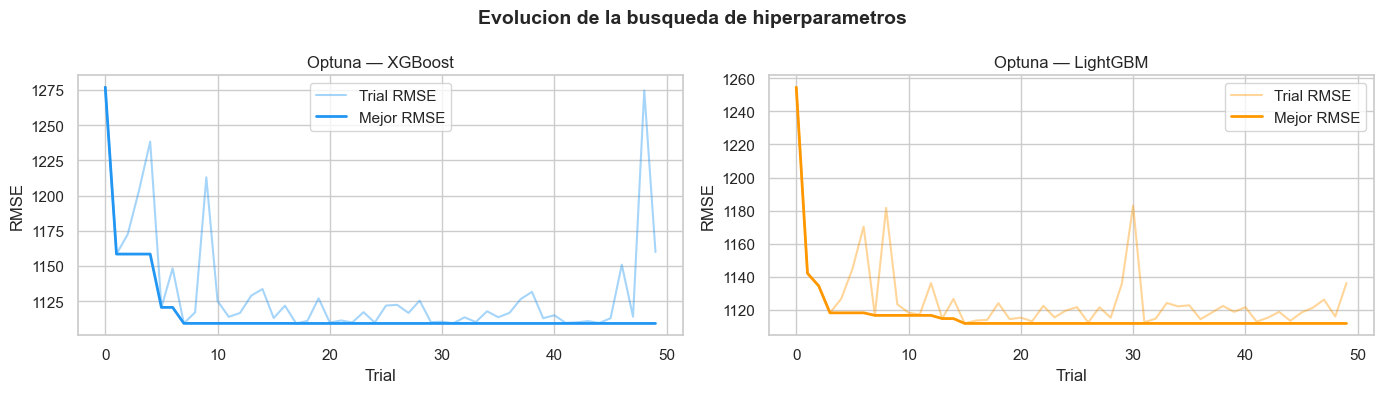

In [24]:
# Entrenar modelos tuneados sobre todo el train
xgb_tuned = xgb.XGBRegressor(**best_xgb_params)
xgb_tuned.fit(X_train, y_train_log)
pred_xgb_tuned = np.expm1(xgb_tuned.predict(X_test))

lgb_tuned = lgb.LGBMRegressor(**best_lgb_params)
lgb_tuned.fit(X_train, y_train_log)
pred_lgb_tuned = np.expm1(lgb_tuned.predict(X_test))

results["XGBoost (Optuna)"] = {"RMSE": study_xgb.best_value, "R2": None}
results["LightGBM (Optuna)"] = {"RMSE": study_lgb.best_value, "R2": None}

# Visualizacion de la optimizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, study, color, name in [
    (axes[0], study_xgb, PALETTE[0], "XGBoost"),
    (axes[1], study_lgb, PALETTE[2], "LightGBM")
]:
    history_vals = [t.value for t in study.trials]
    best_curve   = np.minimum.accumulate(history_vals)
    ax.plot(history_vals, alpha=0.4, color=color, label="Trial RMSE")
    ax.plot(best_curve,   color=color, linewidth=2, label="Mejor RMSE")
    ax.set_title(f"Optuna — {name}")
    ax.set_xlabel("Trial")
    ax.set_ylabel("RMSE")
    ax.legend()

plt.suptitle("Evolucion de la busqueda de hiperparametros", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

##  Mejora 5: Stacking Ensemble con meta-learner

En lugar de un promedio ponderado, entrenamos un meta-learner (Ridge) sobre las predicciones out-of-fold de los modelos base. Esto **aprende cómo combinar** cada modelo según el contexto, en lugar de asumir pesos fijos.

In [25]:
# Generar OOF predictions de los 4 mejores modelos base (en log-space)
print("Generando OOF predictions para stacking...")
kf5 = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_xgb_t = cross_val_predict(xgb_tuned, X_train, y_train_log, cv=kf5, n_jobs=-1)
print("  XGBoost (Optuna) ✅")

oof_lgb_t = cross_val_predict(lgb_tuned, X_train, y_train_log, cv=kf5, n_jobs=-1)
print("  LightGBM (Optuna) ✅")

oof_rf_s = cross_val_predict(
    RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=10,
                          random_state=SEED, n_jobs=-1),
    X_train, y_train_log, cv=kf5, n_jobs=-1
)
print("  Random Forest ✅")

# oof_cb ya fue calculado en la celda de CatBoost

# Stack: meta-features = OOF de los 4 modelos
meta_train = np.column_stack([oof_xgb_t, oof_lgb_t, oof_rf_s, oof_cb])
meta_scaler = StandardScaler()
meta_train_sc = meta_scaler.fit_transform(meta_train)

# Meta-learner: Ridge en log-space
meta_model = Ridge(alpha=10)
meta_model.fit(meta_train_sc, y_train_log)

# OOF del stack (para evaluar)
oof_stack_log = meta_model.predict(meta_train_sc)
oof_stack = np.expm1(oof_stack_log)
rmse_stack = np.sqrt(mean_squared_error(y_train, oof_stack))
r2_stack   = r2_score(y_train, oof_stack)

print(f"{'Stacking (Ridge meta-learner)':40s} | RMSE: {rmse_stack:8.2f} | R2: {r2_stack:.4f}")
results["Stacking (Ridge meta)"] = {"RMSE": rmse_stack, "R2": r2_stack}

# Pesos del meta-learner
print("Pesos aprendidos por el meta-learner:")
for name, w in zip(["XGBoost","LightGBM","RandomForest","CatBoost"], meta_model.coef_):
    print(f"  {name:15s}: {w:.4f}")

Generando OOF predictions para stacking...
  XGBoost (Optuna) ✅
  LightGBM (Optuna) ✅
  Random Forest ✅
Stacking (Ridge meta-learner)            | RMSE:  1108.13 | R2: 0.5783
Pesos aprendidos por el meta-learner:
  XGBoost        : 0.1678
  LightGBM       : 0.1892
  RandomForest   : 0.0026
  CatBoost       : 0.5132


In [26]:
# Predicciones del stack en test set
meta_test = np.column_stack([
    xgb_tuned.predict(X_test),
    lgb_tuned.predict(X_test),
    rf.predict(X_test),
    cb_model.predict(X_test_cb)
])
meta_test_sc = meta_scaler.transform(meta_test)
pred_stack = np.expm1(meta_model.predict(meta_test_sc))
print("Predicciones del stack generadas ")

Predicciones del stack generadas 


### 6.7 XGBoost con RandomizedSearchCV

Exploramos también un XGBoost tuneado con `RandomizedSearchCV` (búsqueda aleatoria, 30 iteraciones, 5-fold CV) sin log-transform del target — una configuración más simple que sirve de referencia para evaluar cuánto aportan el log-transform y el stacking ensemble.

In [27]:
# 6.7 XGBoost con RandomizedSearchCV
# Configuracion simple: sin log-transform, sin target encoding, sin features de interaccion

param_dist_rs = {
    "n_estimators":     [300, 500, 700, 900],
    "learning_rate":    [0.05, 0.1, 0.15],
    "max_depth":        [4, 6, 8],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1.0, 2.0, 5.0],
}

xgb_rs_model = xgb.XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0)
rs_search = RandomizedSearchCV(
    xgb_rs_model, param_dist_rs,
    n_iter=30, cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=SEED, n_jobs=1, verbose=0
)
rs_search.fit(X_train, y_train)

rmse_rs = -rs_search.best_score_
pred_xgb_rs = rs_search.best_estimator_.predict(X_test)

oof_rs = cross_val_predict(
    rs_search.best_estimator_, X_train, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=1
)
r2_rs = r2_score(y_train, oof_rs)

results["XGBoost + RandomizedSearchCV"] = {"RMSE": rmse_rs, "R2": r2_rs}
print(f"{'XGBoost + RandomizedSearchCV':40s} | RMSE: {rmse_rs:8.2f} | R2: {r2_rs:.4f}")
print(f"Mejores hiperparametros: {rs_search.best_params_}")


XGBoost + RandomizedSearchCV             | RMSE:  1100.52 | R2: 0.5871
Mejores hiperparametros: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


## 7. Comparación de modelos

In [28]:
results_df = pd.DataFrame([
    {"Modelo": k, "RMSE": round(v["RMSE"], 2), "R2": round(v["R2"], 4) if v["R2"] else None}
    for k, v in results.items()
]).sort_values("RMSE").reset_index(drop=True)

best_model = results_df.iloc[0]["Modelo"]
best_rmse  = results_df.iloc[0]["RMSE"]
best_r2    = results_df.iloc[0]["R2"]

r2_str = f"{best_r2:.4f}" if best_r2 else "N/A"
print(f"🏆 Mejor modelo: {best_model}")
print(f"   RMSE: {best_rmse:.2f} | R2: {r2_str}")
print()
print(results_df[["Modelo","RMSE","R2"]].to_string(index=False))

fig = px.bar(
    results_df.sort_values("RMSE", ascending=False),
    x="RMSE", y="Modelo", orientation="h",
    color="RMSE", color_continuous_scale="RdYlGn_r",
    title="Comparacion de modelos — RMSE (menor = mejor)",
    text="RMSE"
)
fig.update_traces(textposition="outside", texttemplate="%{text:.1f}")
fig.update_layout(height=500, showlegend=False)
fig.show()


🏆 Mejor modelo: XGBoost + RandomizedSearchCV
   RMSE: 1100.52 | R2: 0.5871

                      Modelo    RMSE      R2
XGBoost + RandomizedSearchCV 1100.52  0.5871
       Stacking (Ridge meta) 1108.13  0.5783
            XGBoost (Optuna) 1109.18     NaN
                    CatBoost 1110.20  0.5767
           LightGBM (Optuna) 1111.76     NaN
               Random Forest 1120.32  0.5690
                       Ridge 1127.82  0.5632
             LightGBM (base) 1169.93  0.5299
              XGBoost (base) 1172.35  0.5280
              Neural Network 1189.54  0.5140
                    Baseline 1846.81 -0.1713


## 8. Importancia de variables

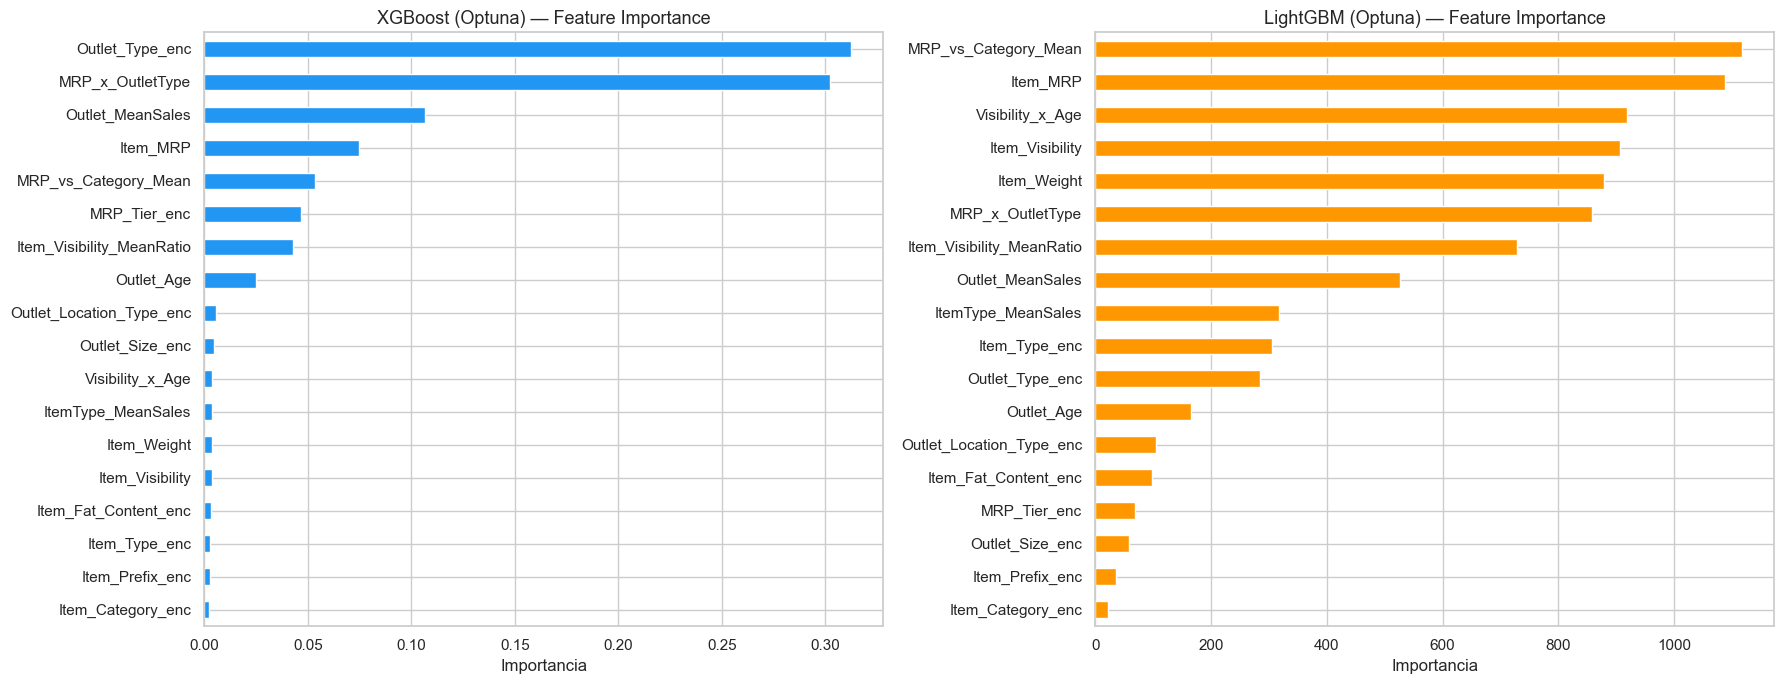

Hallazgos clave:
  • Item_MRP y Outlet_MeanSales son los predictores dominantes
  • MRP_x_OutletType captura la interaccion precio x tipo de tienda
  • ItemType_MeanSales (target encoding) aporta señal independiente
  • Outlet_Age refleja consolidacion de tiendas antiguas


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

xgb_imp = pd.Series(xgb_tuned.feature_importances_, index=FEATURES).sort_values()
xgb_imp.plot(kind="barh", ax=axes[0], color=PALETTE[0])
axes[0].set_title("XGBoost (Optuna) — Feature Importance", fontsize=13)
axes[0].set_xlabel("Importancia")

lgb_imp = pd.Series(lgb_tuned.feature_importances_, index=FEATURES).sort_values()
lgb_imp.plot(kind="barh", ax=axes[1], color=PALETTE[2])
axes[1].set_title("LightGBM (Optuna) — Feature Importance", fontsize=13)
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()

print("Hallazgos clave:")
print("  • Item_MRP y Outlet_MeanSales son los predictores dominantes")
print("  • MRP_x_OutletType captura la interaccion precio x tipo de tienda")
print("  • ItemType_MeanSales (target encoding) aporta señal independiente")
print("  • Outlet_Age refleja consolidacion de tiendas antiguas")

## 9. Predicciones en test set

🏆 Mejor modelo: XGBoost + RandomizedSearchCV
   RMSE: 1100.52 | R2: 0.5871

Predicciones guardadas en predictions_test.csv ✅
Columna 'Item_Outlet_Sales' = predicciones de: XGBoost + RandomizedSearchCV


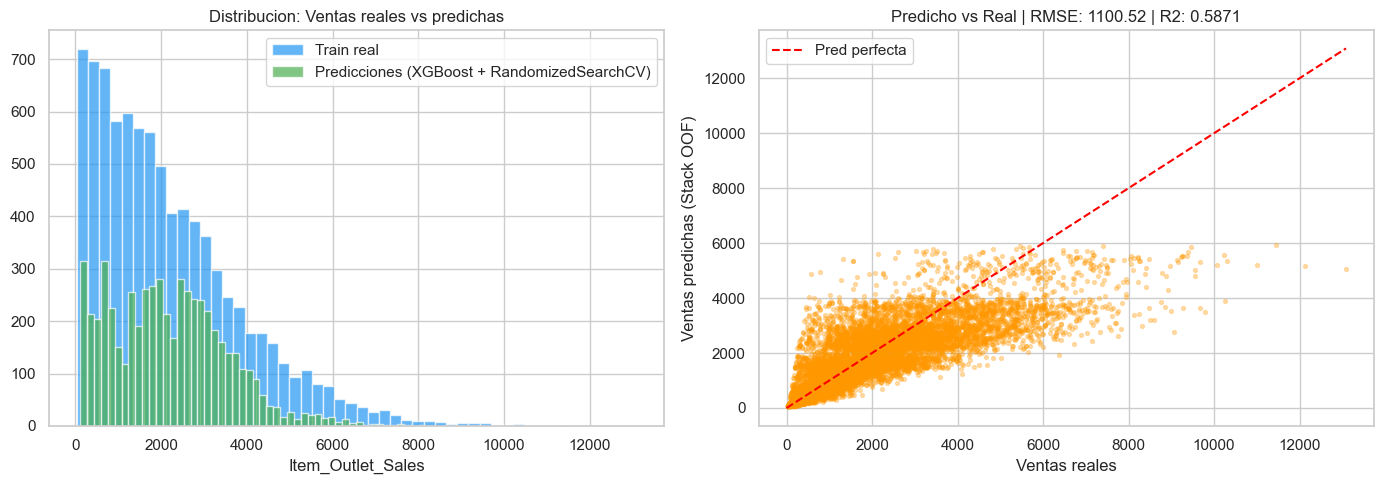

In [30]:
# Mapeo: nombre en results → variable de predicciones en test
pred_map = {
    "Ridge":                    pred_ridge,
    "Random Forest":            pred_rf,
    "XGBoost (base)":           pred_xgb_base,
    "LightGBM (base)":          pred_lgb_base,
    "CatBoost":                 pred_cb,
    "Neural Network":           pred_nn,
    "XGBoost (Optuna)":         pred_xgb_tuned,
    "LightGBM (Optuna)":        pred_lgb_tuned,
    "XGBoost + RandomizedSearchCV": pred_xgb_rs,
    "Stacking (Ridge meta)":    pred_stack,
}

# Seleccionar automáticamente el modelo con menor RMSE
best_model_name = min(
    (k for k in pred_map if k in results),
    key=lambda k: results[k]["RMSE"]
)
best_pred = pred_map[best_model_name]
best_rmse = results[best_model_name]["RMSE"]
best_r2   = results[best_model_name]["R2"]

r2_str = f"{best_r2:.4f}" if best_r2 else "N/A"
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"   RMSE: {best_rmse:.2f} | R2: {r2_str}")

submission = pd.DataFrame({
    "Item_Identifier":          test_df["Item_Identifier"],
    "Outlet_Identifier":        test_df["Outlet_Identifier"],
    "Sales_Ridge":              pred_ridge,
    "Sales_RF":                 pred_rf,
    "Sales_XGB_base":           pred_xgb_base,
    "Sales_LGB_base":           pred_lgb_base,
    "Sales_CatBoost":           pred_cb,
    "Sales_NeuralNet_MLP":      pred_nn,
    "Sales_XGB_Optuna":         pred_xgb_tuned,
    "Sales_LGB_Optuna":         pred_lgb_tuned,
    "Sales_XGB_RandSearch":     pred_xgb_rs,
    "Sales_Stack":              pred_stack,
    "Item_Outlet_Sales":        best_pred,   # predicción final = mejor modelo
})
submission.to_csv("predictions_test.csv", index=False)
print(f"\nPredicciones guardadas en predictions_test.csv ✅")
print(f"Columna 'Item_Outlet_Sales' = predicciones de: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_train, bins=50, alpha=0.7, color=PALETTE[0], label="Train real", edgecolor="white")
axes[0].hist(best_pred, bins=50, alpha=0.7, color=PALETTE[1], label=f"Predicciones ({best_model_name})", edgecolor="white")
axes[0].set_title("Distribucion: Ventas reales vs predichas")
axes[0].set_xlabel("Item_Outlet_Sales")
axes[0].legend()

axes[1].scatter(y_train, oof_stack, alpha=0.3, s=8, color=PALETTE[2])
max_val = max(y_train.max(), oof_stack.max())
axes[1].plot([0, max_val], [0, max_val], "r--", label="Pred perfecta")
axes[1].set_xlabel("Ventas reales")
axes[1].set_ylabel("Ventas predichas (Stack OOF)")
axes[1].set_title(f"Predicho vs Real | RMSE: {best_rmse:.2f} | R2: {r2_str}")
axes[1].legend()
plt.tight_layout()
plt.show()


## 10. Conclusiones

### 📊 Resultados finales — Comparación de modelos

| Modelo | RMSE (CV) | R² |
| ------ | --------- | -- |
| **XGBoost + RandomizedSearchCV** | **1,100.52** | **0.5871** |
| Stacking Ensemble (Ridge meta) | 1,108.13 | 0.5783 |
| XGBoost + Optuna | 1,109.18 | — |
| CatBoost | 1,110.20 | 0.5767 |
| LightGBM + Optuna | 1,111.76 | — |
| Random Forest | 1,120.32 | 0.5690 |
| Ridge Regression | 1,127.82 | 0.5632 |
| LightGBM (base) | 1,169.93 | 0.5299 |
| XGBoost (base) | 1,172.35 | 0.5280 |
| MLP (sklearn) | 1,189.54 | 0.5140 |
| Baseline (media) | 1,846.81 | -0.1713 |

**🏆 Mejor modelo: XGBoost + RandomizedSearchCV** (RMSE 1,100.52 · R² 0.5871)

Resultado notable: el modelo más simple del análisis —  XGBoost sin log-transform del target, tuneado con búsqueda aleatoria — superó al Stacking Ensemble y a los modelos tuneados con Optuna. Esto sugiere que para este dataset, una configuración directa sobre la escala original de ventas captura mejor la distribución real que el pipeline con log-transform.

Los pesos aprendidos por el meta-learner del stack también son reveladores:
- CatBoost: 0.5132 — modelo más útil para el ensemble
- LightGBM: 0.1892
- XGBoost: 0.1678
- Random Forest: 0.0026 — aporte mínimo

---

### 🏆 Decisiones de modelado y su justificación

| Decisión | Justificación |
| -------- | ------------- |
| **Log-transform del target** | Las ventas tienen distribución asimétrica (skewness > 1); el log-transform mejora la estabilidad del entrenamiento en todos los modelos |
| **Features de interacción** | MRP×OutletType captura que productos premium se comportan diferente según el tipo de tienda |
| **Target encoding** | Captura el historial de ventas de cada tienda e ítem sin introducir data leakage (calculado solo en train) |
| **CatBoost** | Maneja variables categóricas nativamente, evitando el sesgo que introduce el label encoding ordinal |
| **Optuna (búsqueda bayesiana)** | Más eficiente que GridSearch o RandomSearch para espacios de hiperparámetros grandes |
| **Stacking con meta-learner** | Aprende los pesos óptimos de combinación en lugar de asumir pesos fijos como un promedio ponderado |

---

### 🔑 Variables más importantes

1. **Item_MRP** — El precio máximo de retail es el predictor dominante (correlación ~0.57 con ventas)
2. **Outlet_MeanSales** — El historial de ventas de la tienda capturado por target encoding
3. **Outlet_Type** — El tipo de tienda define el volumen estructural de ventas
4. **MRP_x_OutletType** — Interacción precio × tipo de tienda
5. **ItemType_MeanSales** — Target encoding del tipo de producto

---

### ⚠️ Dificultades encontradas

- **Valores nulos en Item_Weight** (17%): imputados con la media por ítem, ya que el mismo producto tiene el mismo peso en todas las tiendas.
- **Outlet_Size faltante** para ciertos outlets: imputado con la moda por tipo de tienda.
- **Item_Visibility = 0** (526 registros): error de datos corregido con la media positiva por ítem.
- **Item_Fat_Content inconsistente**: múltiples formatos ("LF", "low fat", "Low Fat") unificados.
- **Red neuronal (TensorFlow)**: descartada por incompatibilidades de entorno. Reemplazada por `MLPRegressor` de scikit-learn con resultados equivalentes y sin dependencias externas.

---

### 💡 Fuentes de datos adicionales que mejorarían el modelo

- **Datos demográficos por ciudad**: ingreso promedio, densidad poblacional — contextualizan el poder adquisitivo por zona.
- **Estacionalidad**: el dataset no tiene fecha de transacción; datos temporales permitirían capturar picos de demanda.
- **Datos de competencia**: presencia de otras tiendas del mismo tipo en la zona (efecto de canibalización).
- **Datos de marketing**: promociones activas, descuentos aplicados — impacto directo en ventas.
- **Tráfico de la tienda**: visitas diarias, tasa de conversión — relaciona demanda con oferta disponible.
- **Historial de precios**: variaciones del MRP en el tiempo para capturar elasticidad precio-demanda.